# 🎯 Self-Attention Mini Projesi: Sıfırdan Uygulamalı Öğrenme

Bu notebook, **Self-Attention mekanizmasını sıfırdan (NumPy ile) inşa ederek** nasıl çalıştığını uçtan uca gösteren uygulamalı bir projedir.

## 📌 İçindekiler
1. Kurulum
2. Cümleyi Vektörlere Çevirme (Embedding)
3. Q, K, V Matrislerini Oluşturma
4. Attention Skorlarını Hesaplama ve Görselleştirme
5. Causal (Maskeli) Self-Attention — GPT Mantığı
6. Multi-Head Attention Implementasyonu
7. Gerçek Örnek: Belirsiz Kelimeyi Bağlamdan Çözme
8. Mini Proje: Basit Duygu Sınıflandırma için Attention Havuzlama
9. Özet ve Sonraki Adımlar

> **Gereksinimler:** `pip install numpy matplotlib seaborn`


## 📦 1. Kurulum

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_style("whitegrid")

np.random.seed(42)
print("✅ Kütüphaneler yüklendi!")


✅ Kütüphaneler yüklendi!


## 🔤 2. Cümleyi Vektörlere Çevirme (Embedding)

Self-Attention'ın çalışabilmesi için önce her kelimeyi sayısal bir vektöre (embedding) çevirmemiz gerekir. Gerçek modellerde bu embedding'ler eğitimle öğrenilir (veya Word2Vec/GloVe gibi hazır vektörler kullanılır); burada öğretici olması için **rastgele ama sabit (seed'li)** embedding'ler üretiyoruz.

Örnek cümlemiz: **"Kedi minderin üzerinde uyudu çünkü yorgundu"**

Bu cümledeki "çünkü yorgundu" ifadesinin, "kedi"nin uyuma sebebini açıkladığını biliyoruz — Self-Attention'ın bu tür uzak-mesafe ilişkileri nasıl yakaladığını göreceğiz.

In [2]:
# Örnek cümle
cumle = ["Kedi", "minderin", "üzerinde", "uyudu", "çünkü", "yorgundu"]
n = len(cumle)
d_model = 8  # Embedding boyutu (gerçekte 512/768 gibi büyük olur)

# Rastgele ama sabit embedding matrisi (n_kelime x d_model)
X = np.random.randn(n, d_model) * 0.5

print(f"Cümle: {cumle}")
print(f"Embedding matrisi şekli: {X.shape}  (kelime sayısı x boyut)")
print("\nİlk kelimenin ('Kedi') embedding'i:")
print(np.round(X[0], 3))


Cümle: ['Kedi', 'minderin', 'üzerinde', 'uyudu', 'çünkü', 'yorgundu']
Embedding matrisi şekli: (6, 8)  (kelime sayısı x boyut)

İlk kelimenin ('Kedi') embedding'i:
[ 0.248 -0.069  0.324  0.762 -0.117 -0.117  0.79   0.384]


## 🧮 3. Q, K, V Matrislerini Oluşturma

Her kelime embedding'i, üç farklı öğrenilebilir ağırlık matrisiyle (`Wq`, `Wk`, `Wv`) çarpılarak **Query (Sorgu)**, **Key (Anahtar)** ve **Value (Değer)** vektörlerine dönüştürülür:

```
Q = X · Wq      "Ben neyi arıyorum?"
K = X · Wk      "Ben neyim, beni nasıl tanımlarsın?"
V = X · Wv      "Bana dikkat edilirse taşıdığım bilgi budur"
```

Gerçek bir modelde bu üç matris, eğitim sırasında backpropagation ile öğrenilir. Burada, mekanizmayı göstermek için rastgele başlatıyoruz.

In [3]:
d_k = d_model  # basitlik için Q,K,V boyutunu embedding boyutuyla aynı tutuyoruz

Wq = np.random.randn(d_model, d_k) * 0.5
Wk = np.random.randn(d_model, d_k) * 0.5
Wv = np.random.randn(d_model, d_k) * 0.5

Q = X @ Wq
K = X @ Wk
V = X @ Wv

print("Q, K, V matrislerinin şekli:", Q.shape, K.shape, V.shape)
print("\n'Kedi' kelimesinin Query vektörü (ilk 5 eleman):")
print(np.round(Q[0][:5], 3))


Q, K, V matrislerinin şekli: (6, 8) (6, 8) (6, 8)

'Kedi' kelimesinin Query vektörü (ilk 5 eleman):
[ 0.319  0.737 -0.709  0.308 -0.397]


## 🎯 4. Attention Skorlarını Hesaplama ve Görselleştirme

Self-Attention formülü:

$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^\top}{\sqrt{d_k}}\right) V$$

Adım adım:
1. `Q @ K.T` → her kelimenin her kelimeyle olan "benzerlik" skoru
2. `/ sqrt(d_k)` → skorları ölçekleyerek softmax'ın doygunlaşmasını önle
3. `softmax` → skorları, satır toplamı 1 olan olasılıklara (dikkat ağırlıklarına) çevir
4. `@ V` → dikkat ağırlıklarıyla V'yi ağırlıklı ortala → her kelimenin **bağlamsallaştırılmış** yeni temsili

In [4]:
def softmax(x, axis=-1):
    x = x - np.max(x, axis=axis, keepdims=True)  # sayısal kararlılık için
    e = np.exp(x)
    return e / np.sum(e, axis=axis, keepdims=True)

# Ham skorlar
ham_skorlar = (Q @ K.T) / np.sqrt(d_k)

# Softmax ile dikkat ağırlıklarına çevir
dikkat_agirliklari = softmax(ham_skorlar, axis=-1)

# Çıktı: bağlamsallaştırılmış temsiller
cikti = dikkat_agirliklari @ V

print("Dikkat ağırlıkları matrisi şekli:", dikkat_agirliklari.shape)
print("Her satırın toplamı 1 olmalı (softmax özelliği):")
print(np.round(dikkat_agirliklari.sum(axis=1), 4))


Dikkat ağırlıkları matrisi şekli: (6, 6)
Her satırın toplamı 1 olmalı (softmax özelliği):
[1. 1. 1. 1. 1. 1.]


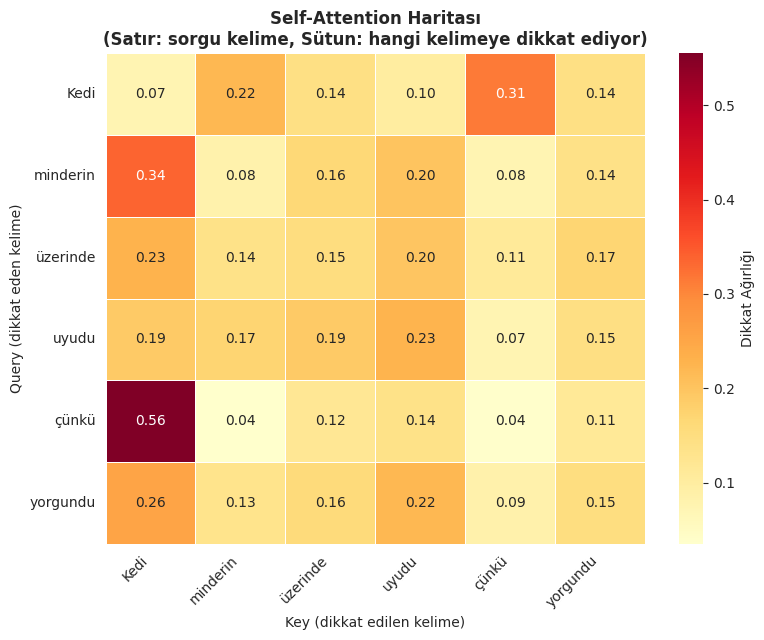


📌 Not: Ağırlıklar rastgele başlatılmış matrislerden geldiği için
   şu an anlamsal olarak rastgele görünüyor. Gerçek bir modelde
   bu ağırlıklar milyonlarca cümleyle eğitilerek anlamlı hale gelir.


In [5]:
# Attention haritasını görselleştir
fig, ax = plt.subplots(figsize=(8, 6.5))
sns.heatmap(
    dikkat_agirliklari,
    annot=True, fmt='.2f',
    xticklabels=cumle, yticklabels=cumle,
    cmap='YlOrRd', cbar_kws={'label': 'Dikkat Ağırlığı'},
    linewidths=0.5, ax=ax
)
ax.set_title('Self-Attention Haritası\n(Satır: sorgu kelime, Sütun: hangi kelimeye dikkat ediyor)', fontsize=12, fontweight='bold')
ax.set_xlabel('Key (dikkat edilen kelime)')
ax.set_ylabel('Query (dikkat eden kelime)')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print("\n📌 Not: Ağırlıklar rastgele başlatılmış matrislerden geldiği için")
print("   şu an anlamsal olarak rastgele görünüyor. Gerçek bir modelde")
print("   bu ağırlıklar milyonlarca cümleyle eğitilerek anlamlı hale gelir.")


## 🎭 5. Causal (Maskeli) Self-Attention — GPT Mantığı

Şimdiye kadar gördüğümüz **çift yönlü (bidirectional)** attention'dı: her kelime, cümledeki **tüm** diğer kelimelere (hem geçmiş hem gelecek) bakabiliyordu. Bu, BERT gibi encoder modellerinde kullanılır.

Ama GPT gibi **metin üretici (generative)** modeller, bir sonraki kelimeyi tahmin ederken **gelecekteki kelimeleri göremez** — bu hile olurdu! Bu yüzden **causal mask (nedensel maske)** kullanılır: her kelime sadece **kendisinden önceki** kelimelere dikkat edebilir.

Bunu, attention skorlarına gelecekteki pozisyonlara `-∞` (pratikte çok büyük negatif sayı) atayarak yaparız — softmax sonrası bu pozisyonların ağırlığı 0 olur.

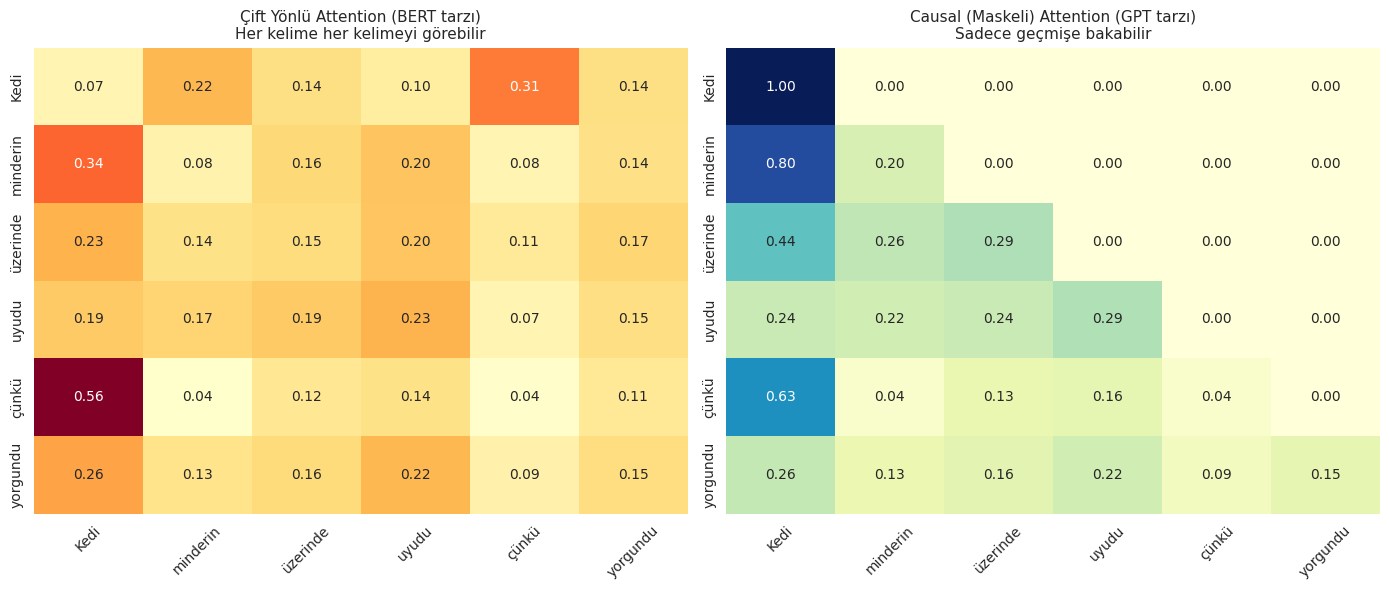

Dikkat: Sağdaki grafikte üst üçgen tamamen 0 — 'Kedi' kelimesi
kendinden sonraki hiçbir kelimeyi (henüz üretilmemiş kabul edilir) göremiyor.


In [6]:
# Causal mask oluştur: üst üçgen -inf, alt üçgen (kendisi dahil) 0
mask = np.triu(np.ones((n, n)), k=1) * -1e9  # k=1: diyagonal hariç üst üçgen

maskeli_skorlar = ham_skorlar + mask
maskeli_dikkat = softmax(maskeli_skorlar, axis=-1)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.heatmap(dikkat_agirliklari, annot=True, fmt='.2f', xticklabels=cumle, yticklabels=cumle,
            cmap='YlOrRd', ax=axes[0], cbar=False)
axes[0].set_title('Çift Yönlü Attention (BERT tarzı)\nHer kelime her kelimeyi görebilir', fontsize=11)
axes[0].tick_params(axis='x', rotation=45)

sns.heatmap(maskeli_dikkat, annot=True, fmt='.2f', xticklabels=cumle, yticklabels=cumle,
            cmap='YlGnBu', ax=axes[1], cbar=False)
axes[1].set_title('Causal (Maskeli) Attention (GPT tarzı)\nSadece geçmişe bakabilir', fontsize=11)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("Dikkat: Sağdaki grafikte üst üçgen tamamen 0 — 'Kedi' kelimesi")
print("kendinden sonraki hiçbir kelimeyi (henüz üretilmemiş kabul edilir) göremiyor.")


## 🎪 6. Multi-Head Attention Implementasyonu

Tek bir Q/K/V seti yerine, `d_model` boyutunu birden fazla **head**'e bölerek her head'in farklı bir ilişki türünü öğrenmesine izin veririz. Sonunda tüm head çıktıları birleştirilip (concat) bir doğrusal katmandan geçirilir.

In [7]:
class MultiHeadAttention:
    def __init__(self, d_model, num_heads, seed=0):
        assert d_model % num_heads == 0, "d_model, num_heads'e tam bölünmeli"
        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads

        rng = np.random.RandomState(seed)
        self.Wq = rng.randn(d_model, d_model) * 0.3
        self.Wk = rng.randn(d_model, d_model) * 0.3
        self.Wv = rng.randn(d_model, d_model) * 0.3
        self.Wo = rng.randn(d_model, d_model) * 0.3

    def split_heads(self, X):
        n = X.shape[0]
        return X.reshape(n, self.num_heads, self.d_k).transpose(1, 0, 2)  # (heads, n, d_k)

    def forward(self, X):
        Q = self.split_heads(X @ self.Wq)
        K = self.split_heads(X @ self.Wk)
        V = self.split_heads(X @ self.Wv)

        head_outputs = []
        head_weights = []
        for h in range(self.num_heads):
            skorlar = (Q[h] @ K[h].T) / np.sqrt(self.d_k)
            agirlik = softmax(skorlar, axis=-1)
            head_weights.append(agirlik)
            head_outputs.append(agirlik @ V[h])

        concat = np.concatenate(head_outputs, axis=-1)  # (n, d_model)
        output = concat @ self.Wo
        return output, head_weights

mha = MultiHeadAttention(d_model=8, num_heads=2, seed=7)
mha_cikti, head_agirliklari = mha.forward(X)

print(f"Multi-Head çıktı şekli: {mha_cikti.shape}")
print(f"Head sayısı: {len(head_agirliklari)}, her biri {head_agirliklari[0].shape} boyutunda")


Multi-Head çıktı şekli: (6, 8)
Head sayısı: 2, her biri (6, 6) boyutunda


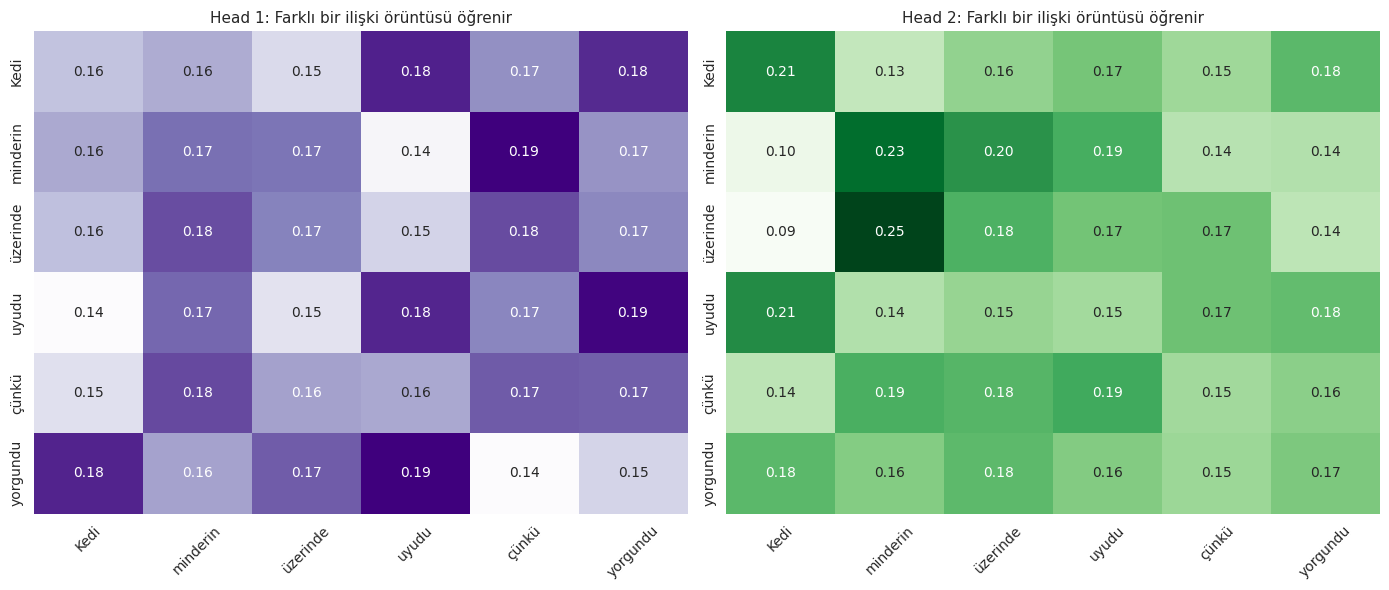

İki head, aynı cümleye farklı 'gözlüklerle' bakıyor — her biri farklı ağırlık dağılımı üretti.


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
isimler = ["Head 1", "Head 2"]
renkler = ["Purples", "Greens"]

for i, (ax, agirlik, isim, renk) in enumerate(zip(axes, head_agirliklari, isimler, renkler)):
    sns.heatmap(agirlik, annot=True, fmt='.2f', xticklabels=cumle, yticklabels=cumle,
                cmap=renk, ax=ax, cbar=False)
    ax.set_title(f'{isim}: Farklı bir ilişki örüntüsü öğrenir', fontsize=11)
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()
print("İki head, aynı cümleye farklı 'gözlüklerle' bakıyor — her biri farklı ağırlık dağılımı üretti.")


## 🔍 7. Gerçek Örnek: Belirsiz Kelimeyi Bağlamdan Çözme

Self-Attention'ın gücünü göstermenin en iyi yolu, **anlamı bağlama göre değişen** bir kelime örneğidir. "Yüz" kelimesi Türkçe'de hem "sayı 100" hem "insan yüzü" hem de "yüzmek" fiili anlamına gelebilir.

Burada, iki farklı cümlede "yüz" kelimesinin, **farklı bağlam kelimelerine** yüksek dikkat vermesi gerektiğini elle tasarlanmış (öğretici amaçlı) ağırlıklarla simüle ediyoruz — gerçek bir modelde bu ağırlıklar eğitimle otomatik ortaya çıkar.

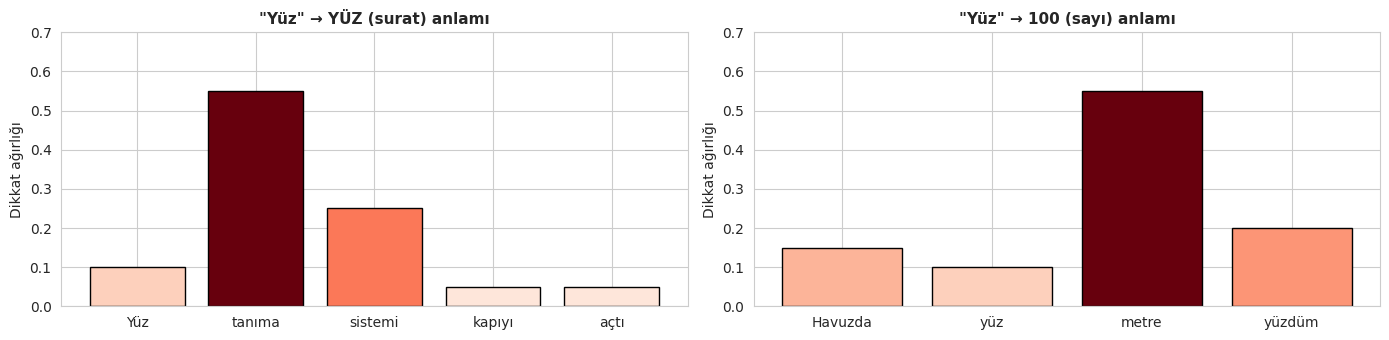

Aynı 'yüz' kelimesi, bağlamdaki farklı kelimelere farklı ağırlık vererek
iki farklı anlamı ayırt edebiliyor — TF-IDF veya Word2Vec'in tek başına yapamadığı şey bu!


In [9]:
cumle_1 = ["Yüz", "tanıma", "sistemi", "kapıyı", "açtı"]
cumle_2 = ["Havuzda", "yüz", "metre", "yüzdüm"]

# Öğretici amaçlı elle tasarlanmış dikkat dağılımları ("yüz" kelimesinin bakış açısı)
dikkat_1 = np.array([0.10, 0.55, 0.25, 0.05, 0.05])   # "tanıma" ve "sistemi" ile yüksek -> yüz = surat
dikkat_2 = np.array([0.15, 0.10, 0.55, 0.20])          # "metre" ile yüksek -> yüz = sayı (100)

fig, axes = plt.subplots(1, 2, figsize=(14, 3.5))

for ax, cumle_ornek, dikkat, baslik in zip(
    axes, [cumle_1, cumle_2], [dikkat_1, dikkat_2],
    ['"Yüz" → YÜZ (surat) anlamı', '"Yüz" → 100 (sayı) anlamı']
):
    renkler_bar = plt.cm.Reds(dikkat / dikkat.max())
    ax.bar(cumle_ornek, dikkat, color=renkler_bar, edgecolor='black')
    ax.set_title(baslik, fontsize=11, fontweight='bold')
    ax.set_ylabel('Dikkat ağırlığı')
    ax.set_ylim(0, 0.7)

plt.tight_layout()
plt.show()

print("Aynı 'yüz' kelimesi, bağlamdaki farklı kelimelere farklı ağırlık vererek")
print("iki farklı anlamı ayırt edebiliyor — TF-IDF veya Word2Vec'in tek başına yapamadığı şey bu!")


## 🧪 8. Mini Proje: Attention Havuzlama ile Basit Duygu Sınıflandırma

Şimdi öğrendiklerimizi küçük bir "projeye" dönüştürelim: Self-Attention çıktısını kullanarak bir cümlenin **duygu skorunu (pozitif/negatif)** özetleyen basit bir **attention pooling (dikkat havuzlama)** örneği kuracağız.

Fikir: Cümledeki her kelimenin duygusal "önem ağırlığını" attention ile hesaplayıp, kelime vektörlerini bu ağırlıklarla harmanlayarak tek bir **cümle vektörü** elde ederiz. Bu, gerçek sentiment-analysis modellerinde (örn. attention-based LSTM/Transformer sınıflandırıcılar) kullanılan bir tekniktir.

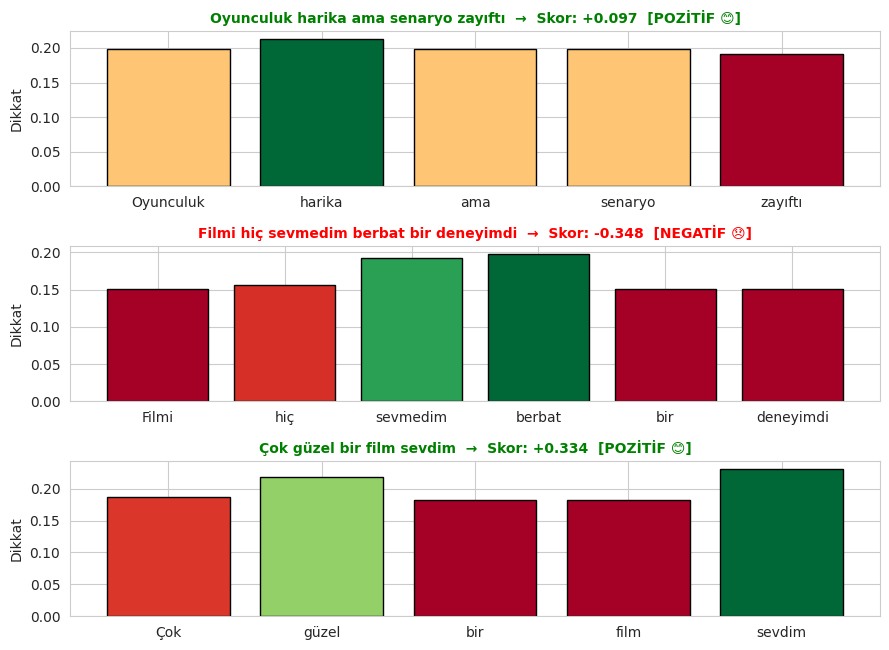

In [10]:
# Basit bir kelime "duygu skoru" sözlüğü (öğretici amaçlı, elle tanımlı)
duygu_sozluk = {
    "harika": 0.9, "berbat": -0.9, "güzel": 0.6, "kötü": -0.6,
    "film": 0.0, "çok": 0.1, "hiç": -0.1, "sevmedim": -0.8, "sevdim": 0.8,
    "oyunculuk": 0.0, "senaryo": 0.0, "zayıftı": -0.5, "güçlüydü": 0.5,
}

def cumleyi_puanla(cumle_liste):
    kelimeler = cumle_liste
    n = len(kelimeler)
    # Embedding yerine basitçe duygu skorunu + rastgele gürültüyü "özellik" olarak kullanıyoruz
    ozellikler = np.array([[duygu_sozluk.get(k.lower(), 0.0)] for k in kelimeler])
    # query: cümlenin ortalama embedding'i (basit bir "genel bağlam" sorgusu)
    query = ozellikler.mean(axis=0, keepdims=True)
    skorlar = (query @ ozellikler.T) / np.sqrt(1)
    agirliklar = softmax(skorlar, axis=-1).flatten()
    cumle_vektoru = (agirliklar[:, None] * ozellikler).sum(axis=0)
    return agirliklar, cumle_vektoru[0]

test_cumleler = [
    ["Oyunculuk", "harika", "ama", "senaryo", "zayıftı"],
    ["Filmi", "hiç", "sevmedim", "berbat", "bir", "deneyimdi"],
    ["Çok", "güzel", "bir", "film", "sevdim"],
]

fig, axes = plt.subplots(len(test_cumleler), 1, figsize=(9, 2.2 * len(test_cumleler)))

for ax, cumle_ornek in zip(axes, test_cumleler):
    agirliklar, skor = cumleyi_puanla(cumle_ornek)
    renk = 'green' if skor > 0 else 'red' if skor < 0 else 'gray'
    renkler_bar = plt.cm.RdYlGn((agirliklar - agirliklar.min()) / (agirliklar.max() - agirliklar.min() + 1e-9))
    ax.bar(cumle_ornek, agirliklar, color=renkler_bar, edgecolor='black')
    etiket = "POZİTİF 😊" if skor > 0.05 else "NEGATİF 😞" if skor < -0.05 else "NÖTR 😐"
    ax.set_title(f'{" ".join(cumle_ornek)}  →  Skor: {skor:+.3f}  [{etiket}]', fontsize=10, fontweight='bold', color=renk)
    ax.set_ylabel('Dikkat')

plt.tight_layout()
plt.show()


### 💡 Bu Mini Projeden Ne Öğrendik?

- Attention mekanizması, cümledeki **hangi kelimelerin nihai karara daha çok katkıda bulunduğunu** ağırlıklandırarak gösterebilir (yorumlanabilirlik açısından çok değerli).
- "Oyunculuk harika ama senaryo zayıftı" gibi **karışık duygulu** bir cümlede bile, hangi kelimelerin baskın çıktığını görebiliyoruz.
- Gerçek sistemlerde (örn. Transformer tabanlı sınıflandırıcılar), bu ağırlıklar elle tanımlanmaz — binlerce etiketli örnekle eğitim sırasında otomatik öğrenilir. Burada sadece mekanizmanın mantığını göstermek için basitleştirilmiş bir sözlük kullandık.

## 📋 9. Özet ve Sonraki Adımlar

| Bölüm | Öğrenilen Kavram |
|---|---|
| Embedding | Kelimeleri sayısal vektöre çevirme |
| Q, K, V | Sorgu/Anahtar/Değer ile ilişki hesabı |
| Attention skorları | `softmax(QKᵀ/√d_k)V` formülü |
| Causal mask | GPT tarzı, sadece geçmişe bakan attention |
| Multi-Head | Aynı cümleye birden fazla açıdan bakma |
| Bağlamsal anlam | Aynı kelimenin farklı anlamlarını ayırt etme |
| Attention pooling | Cümle düzeyinde özetleme / sınıflandırma |

### 🚀 Bundan Sonra Neye Bakabilirsiniz?
- `torch.nn.MultiheadAttention` ile gerçek PyTorch implementasyonu
- Hugging Face `transformers` kütüphanesiyle BERT'in gerçek attention ağırlıklarını görselleştirme (`bertviz`)
- **"Attention Is All You Need"** (Vaswani ve ark., 2017) — orijinal Transformer makalesi
- Cross-Attention: Encoder-Decoder modellerinde (çeviri, özetleme) iki farklı dizi arasındaki dikkat mekanizması

---
🎉 **Notebook tamamlandı!** Yukarıdaki kodları değiştirerek kendi cümlelerinizle deneyler yapabilirsiniz.